# Building An Operator

Author : Henry Nachman

---

This tutorial will dive into the workings of `Operators` in TOAST. What they are, how they operate (pun intended), and the basics of how to build your own.

In [81]:
import toast
from toast.tests import helpers
from plotting_utils import *


## What is an Operator

An `Operator` is an object with methods which can be applied to `Data` objects. Each `operator` is built on the base `Operator` class. This means that `operators` _inherit_ the methods of the parent `Operator` class.

To illustrate the concept of _inheritance_ in python take the follow code example.

```python
# The parent (base) class
class Animal:
    def __init__(self, name):
        self.name = name

    def eat(self):
        print(f"{self.name} is eating.")

# The child (derived) class that "is a type of" Animal
class Dog(Animal):
    def bark(self):
        print(f"{self.name} says woof!")
```

In this case, the `Dog` class has its own methods (`bark`) but also inherits the `eat` method from the base `Animal` class. 

In TOAST, the `Operator` base class has two primary methods briefly described by their docstrings below (there are other methods but these are the most important and relevant ones):

```python
class Operator(TraitConfig):
    def exec(self, data, detectors=None, **kwargs):
        """Perform operations on a Data object.

        If a list of detectors is specified, only process these detectors.  Any extra
        kwargs are passed to the derived class internal method.

        Accelerator use:  If the derived class supports OpenMP target offload and all the required
        data objects exist on the device, then the `_exec()` method will be called
        with the "use_accel=True" option.  Any operator that returns "True" from its
        _supports_accel() method should also accept the "use_accel" keyword argument.

        Args:
            data (toast.Data):  The distributed data.
            detectors (list):  A list of detector names or indices.  If None, this
                indicates a list of all detectors.

        Returns:
            None

        """

    @function_timer_stackskip
    def apply(self, data, detectors=None, **kwargs):
        """Run exec() and finalize().

        This is a convenience wrapper that calls exec() exactly once with an optional
        detector list and then immediately calls finalize().  This is really only
        useful when working interactively to save a bit of typing.  When a `Pipeline`
        is calling other operators it will always use exec() and finalize() explicitly.

        After calling this, any future calls to exec() may produce unexpected results,
        since finalize() has already been called.

        Args:
            data (toast.Data):  The distributed data.
            detectors (list):  A list of detector names or indices.  If None, this
                indicates a list of all detectors.

        Returns:
            (value):  None or an Operator-dependent result.

        """
```

An example of an operator in TOAST is the `PointingDetectorSimple` operator.

Let's create this operator object.

In [82]:
pointing_operator = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_azel,
    quats="quats_azel"
)

Here we have created an instance of the `PointingDetectorSimple` Operator. The two arguments we gave it are specific attributes of the `PointingDetectorSimple` class. The `PointingDetectorSimple` class has a number of attributes not specified in this object instantiation because each attribute has a default value. In the case of `PointingDetectorSimple`, the default value for the `boresight` attribute is the `boresight_radec`, we call the `Operator` with arguments to overwrite the defaults.

```python
    boresight = Unicode(
        defaults.boresight_radec, help="Observation shared key for boresight"
    )
```

Now that we have our operator, we can apply the operator to our data with the following.

In [98]:
# Let's first make make a fake observation. Before we can do that we need to define a telescope. And to do that we need to define a focal plane
from toast.instrument_sim import fake_hexagon_focalplane
from astropy import units as u

focalplane = fake_hexagon_focalplane(
    n_pix=19,
    width=10.0 * u.degree,
    sample_rate=10.0 * u.Hz,
    epsilon=0.0,
)

telescope = toast.Telescope(name="fake", focalplane=focalplane, site=toast.SpaceSite(name="L2"))


ob = toast.Observation(
    toast.Comm(),
    telescope, 
    name="test_obs", 
    n_samples=30
)

ob.detdata["signal"] = {
    x: np.ones((ob.n_local_samples, 2), dtype=np.int16)
        for x in ob.local_detectors
}

# Start with an empty data container
data = toast.Data()
data.obs = [ob]


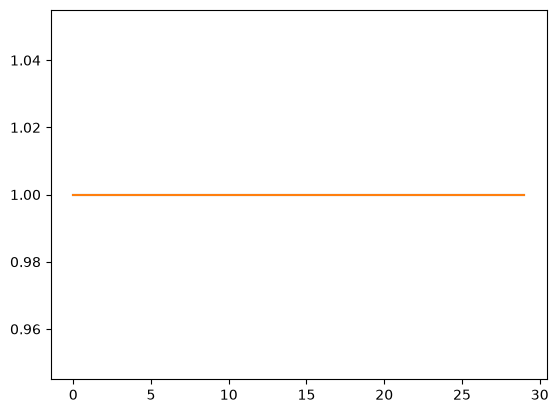

In [99]:
plt.plot(ob.detdata['signal'][0])

And like that we have applied our pointing operator to the observation data. 

What is happening in the back-end?

Well first, operator calls on the `apply` method. You might notice by taking a peek at the source code that the `PointingDetectorSimple` class does not have its own `apply` method. That means, it is _inheriting_ the `apply` method from the general `Operator` class.

The `apply` method of the parent `Operator` class runs the `exec` function. This jumps to the `exec` method in the `Operator` parent class. This in turn jumps to the `_exec` method in the specific operator.

In the case of the `PointingDetectorSimple` Operator, we see that this is where the information for how to adjust the detector pointing is encoded (and then passed to the `pointing_detector` function).

## A Simple Operator

In [102]:
from toast.ops.operator import Operator
from toast.timing import function_timer
from traitlets import Unicode, Int

In [103]:
class TestOperator(Operator):
    name = Unicode(
        "Test Operator",
        help = "The designated name of this operator"
    )

    @function_timer
    def _exec(self, data, detectors=None, use_accel=None, **kwargs):
        print(self.name)
        return

    def _finalize(self, data, **kwargs):
        return

This is a very basic example of an operator. Notice it contains two _mandatory_ methods: the `_exec` and the `_finalize` methods. Without these, toast will through an error.

In [104]:
henry_operator = TestOperator(name = "Henry Operator")

henry_operator.apply(data)

Henry Operator


Let's make another operator - this one that actually does something:

In [139]:
class ToInfinityAndBeyond(Operator):
    """
    Description: The purpose of this operator is to make a detector time stream that slowly increasing...
    To infinity and beyond.
    """

    rate = Int(
        5,
        "The rate of increase of the data."
    )

    @function_timer
    def _exec(self, data, detectors=None, use_accel=None, **kwargs):
        # print(self.rate)
        # Make an array of the length of data
        data_shape = np.shape(data.obs[0].detdata["signal"])
        # print(data_shape)
        n_samp = data_shape[1]
        new_data = np.polyval([self.rate, 0], np.arange(n_samp))
        # print(new_data)

        for ob in data.obs:
            # print(ob.detdata["signal"].keys())
            if detectors is not None:
                for detector in detectors:
                    # print(ob.detdata["signal"][detector])
                    ob.detdata["signal"][detector][:, 0] = new_data
                    # print(ob.detdata["signal"][detector])

        return
    
    def _finalize(self, data, **kwargs):
        return

In [141]:
slow_increase = ToInfinityAndBeyond(rate=2)

slow_increase.apply(data, detectors = ["D00A-150"])

In [142]:
print(ob.detdata)

<DetDataManager 38 local detectors, 30 samples
    signal: shape=(38, 30, 2), dtype=int16, units=''>


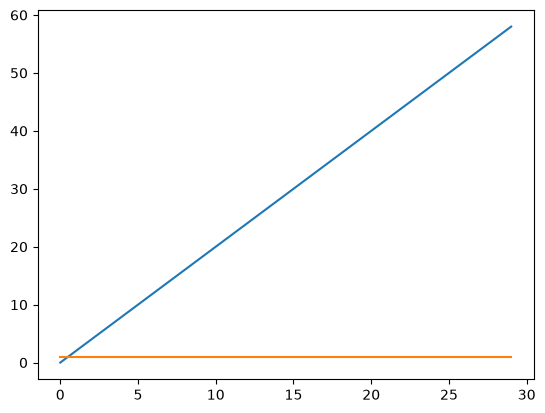

In [143]:
import matplotlib.pyplot as plt

plt.plot(ob.detdata['signal'][0])